In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
X, y = make_moons(n_samples=500, noise = 0.2, random_state=42)

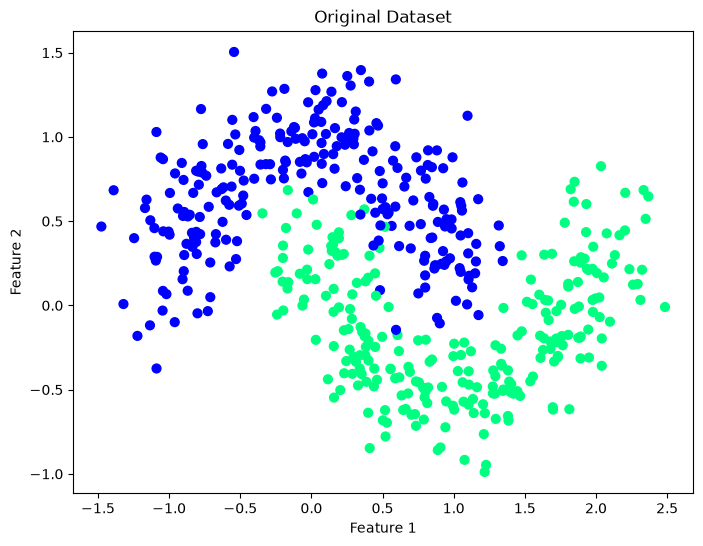

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(X[:,0],X[:,1], c=y, cmap="winter", s=40)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")

plt.show()

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [9]:
poly_logistic = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("logistic", LogisticRegression(max_iter=5000))
])

poly_logistic.fit(X_train,y_train)

y_pred  = poly_logistic.predict(X_test)

In [10]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))

Accuracy Score:  0.96


In [11]:
print("\n Confusion Matrix")
pd.DataFrame(confusion_matrix(y_test,y_pred))


 Confusion Matrix


,0,1
0,43,0
1,4,53


<Axes: >

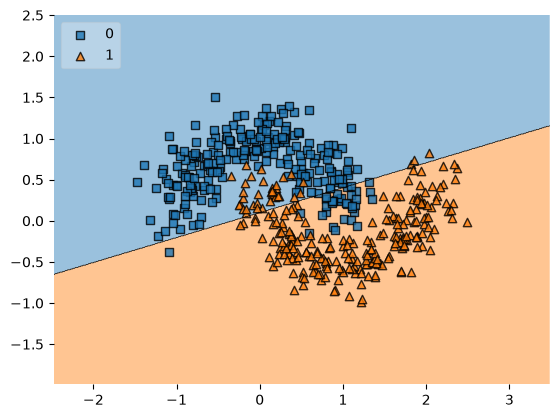

In [16]:
clf = LogisticRegression(max_iter=10000)
clf.fit(X,y)
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype(int), clf, legend=2)

In [17]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf, X_train, y_train, scoring ="accuracy", cv = 10))

np.float64(0.8525)

In [18]:
poly = PolynomialFeatures(degree=3,include_bias=False)
X_trf = poly.fit_transform(X)

clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

np.float64(0.96)

In [22]:
def plot_decision_boundary(X,y,degree=1):

    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf,y)

    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy', cv =10))

    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)

    XX,YY = np.meshgrid(a,b)

    input_array = np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))

    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

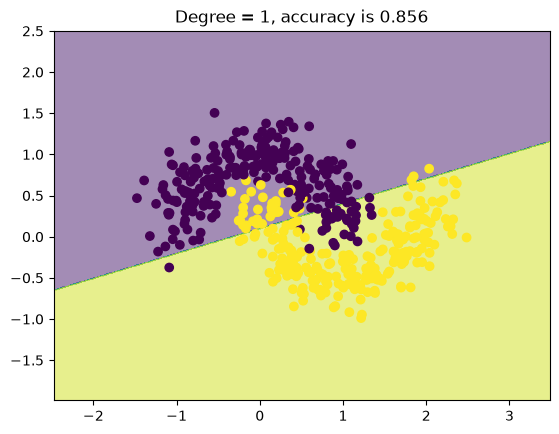

In [23]:
plot_decision_boundary(X,y)

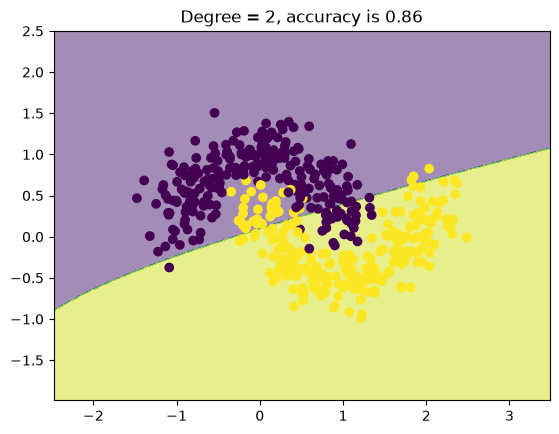

In [24]:
plot_decision_boundary(X,y,degree=2)

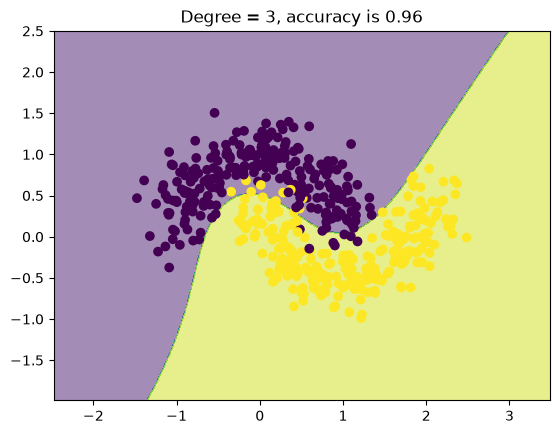

In [25]:
plot_decision_boundary(X,y,degree=3)

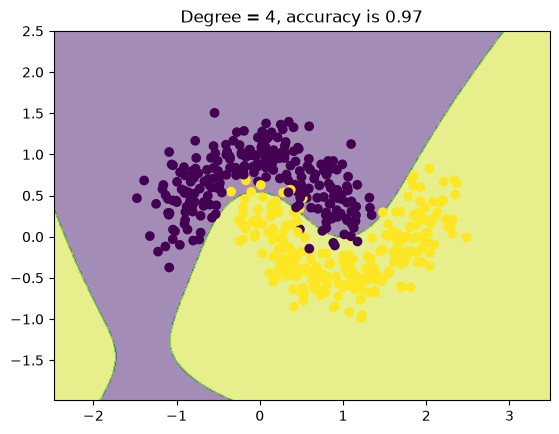

In [26]:
plot_decision_boundary(X,y,degree=4)

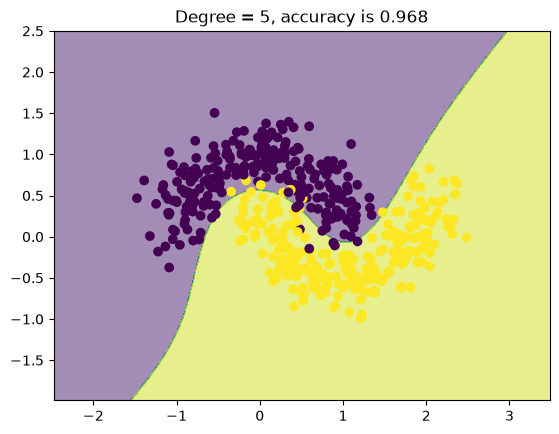

In [27]:
plot_decision_boundary(X,y,degree=5)

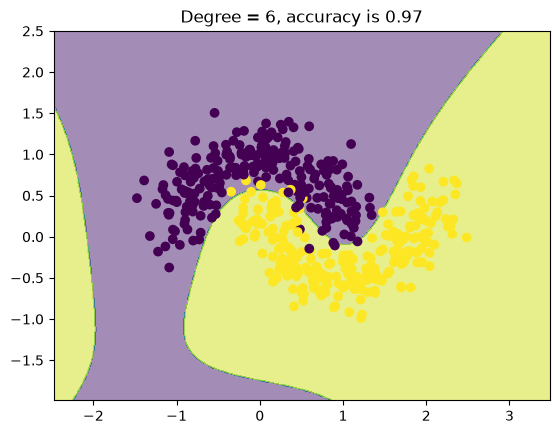

In [28]:
plot_decision_boundary(X,y,degree=6)

C:\Users\KESHAV\Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\KESHAV\Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepr

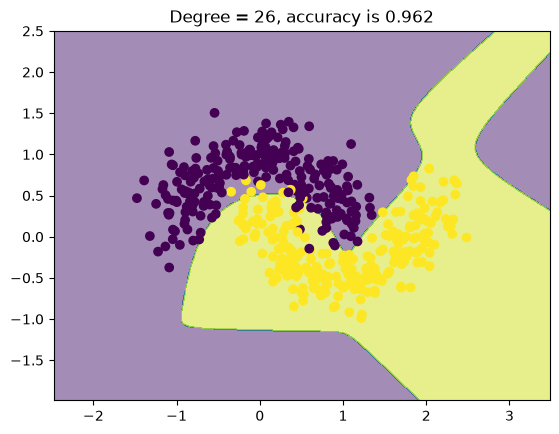

In [29]:
plot_decision_boundary(X,y,degree=26)